In [5]:
from __future__ import annotations

from typing import Optional, Sequence, Tuple, Union

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

try:
    # 与仓库一致：默认使用 ImageNet 归一化统计量
    from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
    _DEFAULT_MEAN: Tuple[float, float, float] = (
        float(IMAGENET_DEFAULT_MEAN[0]),
        float(IMAGENET_DEFAULT_MEAN[1]),
        float(IMAGENET_DEFAULT_MEAN[2]),
    )
    _DEFAULT_STD: Tuple[float, float, float] = (
        float(IMAGENET_DEFAULT_STD[0]),
        float(IMAGENET_DEFAULT_STD[1]),
        float(IMAGENET_DEFAULT_STD[2]),
    )
except Exception:
    _DEFAULT_MEAN = (0.485, 0.456, 0.406)
    _DEFAULT_STD = (0.229, 0.224, 0.225)


def denormalize_images(
    images: torch.Tensor,
    mean: Sequence[float] = _DEFAULT_MEAN,
    std: Sequence[float] = _DEFAULT_STD,
) -> torch.Tensor:
    """将经 Normalize 处理的图像反归一化。

    Args:
        images: 形状为 (C, H, W) 或 (B, C, H, W) 的张量，值已被标准化。
        mean: 标准化所用均值（长度 C）。
        std: 标准化所用方差（长度 C）。

    Returns:
        与输入形状相同的张量，值被还原并裁剪到 [0, 1] 范围。
    """
    if images.ndim == 3:
        images = images.unsqueeze(0)
    if images.ndim != 4:
        raise ValueError(f"Expected (C,H,W) or (B,C,H,W), got shape {tuple(images.shape)}")

    device = images.device
    dtype = images.dtype
    mean_t = torch.tensor(mean, device=device, dtype=dtype).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=device, dtype=dtype).view(1, -1, 1, 1)

    out = images * std_t + mean_t
    return out.clamp(0.0, 1.0)


def show_images(
    images: Union[torch.Tensor, Sequence[torch.Tensor]],
    nrow: int = 8,
    mean: Sequence[float] = _DEFAULT_MEAN,
    std: Sequence[float] = _DEFAULT_STD,
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (10, 10),
    save_path: Optional[str] = None,
) -> None:
    """可视化被 Normalize 的图像（自动反归一化）。

    支持 (C,H,W) 或 (B,C,H,W) 的张量，或若干 (C,H,W) 张量组成的序列。

    Args:
        images: 输入图像。
        nrow: 批量可视化时每行的图像数量。
        mean: 标准化所用均值。
        std: 标准化所用方差。
        title: 图标题。
        figsize: Matplotlib 图像尺寸。
        save_path: 若提供则保存到该路径，否则直接显示。
    """
    if isinstance(images, (list, tuple)):
        # 将若干 (C,H,W) 堆叠为 (B,C,H,W)
        images = torch.stack([img if img.ndim == 3 else img.squeeze(0) for img in images], dim=0)
    elif isinstance(images, torch.Tensor) and images.ndim == 3:
        images = images.unsqueeze(0)

    if not isinstance(images, torch.Tensor) or images.ndim != 4:
        raise ValueError("images 必须是形状为 (B,C,H,W) 或 (C,H,W) 的 Tensor，或其列表。")

    images = denormalize_images(images, mean=mean, std=std)
    grid = make_grid(images, nrow=nrow, padding=2)
    grid_np = grid.permute(1, 2, 0).detach().cpu().numpy()

    plt.figure(figsize=figsize)
    plt.imshow(grid_np)
    plt.axis("off")
    if title is not None:
        plt.title(title)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()
        plt.close()

# 示例（按需取消注释）：
# show_images(batch_images[:16], title="训练批次样例")



/data/home/jlchen/miniconda3/envs/vla/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:


model_checkpoint = "/data/home/jlchen/code/UniVLA/vla-scripts/vla_log/InternVL3_5-1B-Instruct-HF+droid_100+n8+b4+x42--image_aug-Latent-Action-Pretraining/checkpoints"
# model_checkpoint = "OpenGVLab/InternVL3_5-1B-HF"
from transformers import AutoProcessor, AutoModel,InternVLForConditionalGeneration
import torch

torch_device = "cuda"

processor = AutoProcessor.from_pretrained(model_checkpoint)
model = InternVLForConditionalGeneration.from_pretrained(model_checkpoint, device_map=torch_device, torch_dtype=torch.bfloat16,trust_remote_code=True)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "http://images.cocodataset.org/val2017/000000039769.jpg"},
            {"type": "text", "text": "Please describe the image explicitly."},
        ],
    }
]

inputs = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt").to(model.device, dtype=torch.bfloat16)

generate_ids = model.generate(**inputs, max_new_tokens=50)
decoded_output = processor.decode(generate_ids[0, inputs["input_ids"].shape[1] :], skip_special_tokens=True)

decoded_output






Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


'The image shows two cats lying on a pink surface. The cat on the left is a tabby with a striped pattern, and the cat on the right is also a tabby with a similar striped pattern. Both cats appear to be sleeping or resting'

In [6]:
# VLA Dataloader 测试脚本
# 测试 train.py 中 run_latent_action_training 内部的 dataloader 实现

import os
import sys
import json
import torch
import torch.nn as nn
from pathlib import Path
from typing import Dict, Any, Optional, Tuple
from dataclasses import dataclass, asdict
import yaml
from torch.utils.data import DataLoader
from transformers.tokenization_utils_base import PreTrainedTokenizerBase
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 添加项目路径
sys.path.append('/data/home/jlchen/code/UniVLA')

# 导入必要的模块
from latent_action_model.core.lam_model import LatentLAMModel
from prismatic.models.vlms import PrismaticVLM
from prismatic.vla import get_latent_vla_dataset_and_collator
from prismatic.vla.datasets.datasets import RLDSDataset
from prismatic.util.data_utils import PaddedCollatorForActionPrediction
from prismatic.overwatch import initialize_overwatch
from prismatic.util import set_global_seed

# 初始化日志
overwatch = initialize_overwatch(__name__)

print("✅ 导入模块成功")


2025-09-12 19:25:24.094791: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-12 19:25:24.129450: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-12 19:25:24.129475: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-12 19:25:24.130766: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-12 19:25:24.137191: I tensorflow/core/platform/cpu_feature_guar

✅ 导入模块成功


In [7]:
# 配置类定义（从 train.py 复制）
@dataclass
class TestConfig:
    """测试配置类，基于 TrainConfig 简化版本"""
    
    # 数据路径配置
    data_root_dir: Path = Path("/data/home/jlchen/datasets")  # 需要修改为实际路径
    lam_path: str = "latent_action_model/logs/vjepa_lam/last.ckpt"
    
    # 模型配置
    model_id: str = 'OpenGVLab/InternVL3_5-1B-HF'
    hf_cache_dir: Optional[Path] = None
    hf_token: Optional[str] = None
    
    # LAM 模型参数
    dim: int = 1024
    enc_layers: int = 6
    codebook_size: int = 16
    code_dim: int = 256
    dec_layers: int = 6
    dec_self_heads: int = 4
    dec_cross_heads: int = 4
    dropout: float = 0.1
    num_queries: int = 4
    
    # 数据配置
    data_mix: str = "droid_100"
    shuffle_buffer_size: int = 20_000
    image_resolution: int = 448
    image_aug: bool = True
    
    # 训练配置
    per_device_batch_size: int = 10 # 测试时使用小批次
    device_id: int = 0
    
    # 特殊 token 配置
    action_token_begin_id: int = 151679

print("✅ 配置类定义完成")


✅ 配置类定义完成


In [8]:
# 初始化配置和检查环境
def setup_test_environment():
    """设置测试环境"""
    
    # 设置环境变量
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    
    # 检查 CUDA 可用性
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🔧 使用设备: {device}")
    
    # 设置随机种子
    set_global_seed(42)
    
    # 创建测试配置
    cfg = TestConfig()
    
    # 检查关键文件是否存在
    print("📁 检查关键文件:")
    print(f"   - LAM 模型路径: {cfg.lam_path}")
    if Path(cfg.lam_path).exists():
        print("   ✅ LAM 模型文件存在")
    else:
        print("   ❌ LAM 模型文件不存在")
    
    print(f"   - 数据根目录: {cfg.data_root_dir}")
    if cfg.data_root_dir.exists():
        print("   ✅ 数据根目录存在")
    else:
        print("   ❌ 数据根目录不存在")
    
    return cfg, device

# 执行环境设置
cfg, device = setup_test_environment()
print("✅ 测试环境设置完成")


🔧 使用设备: cuda
📁 检查关键文件:
   - LAM 模型路径: latent_action_model/logs/vjepa_lam/last.ckpt
   ✅ LAM 模型文件存在
   - 数据根目录: /data/home/jlchen/datasets
   ✅ 数据根目录存在
✅ 测试环境设置完成


In [9]:
# 加载基础 VLM 模型
def load_base_vlm(cfg: TestConfig):
    """加载基础 VLM 模型（InternVL）"""
    
    print("🔄 加载基础 VLM 模型...")
    

    # 加载 VLM 模型
    vlm = PrismaticVLM.from_pretrained(
        cfg.model_id,
        token=cfg.hf_token,
        cache_dir=str(cfg.hf_cache_dir) if cfg.hf_cache_dir is not None else None,
        trust_remote_code=True,
        device_map="cpu",
    )

    
    # 验证模型精度
    for param in vlm.parameters():
        assert param.dtype == torch.float32, f"Loaded VLM parameter not in full precision: {param}"
    
    # 冻结模块（测试时全部冻结）
    vlm.freeze_modules(
        vision_encoder=True,
        llm_backbone=True,
        projector=True,
        llm_head=True,
    )
    
    # 打印参数统计
    num_params = sum(p.numel() for p in vlm.parameters())
    num_trainable_params = sum(p.numel() for p in vlm.parameters() if p.requires_grad)
    print(f"📊 模型参数统计:")
    print(f"   - 总参数: {num_params / 10**6:.3f}M")
    print(f"   - 可训练参数: {num_trainable_params / 10**6:.3f}M")
    
    return vlm
        


# 加载 VLM 模型
vlm = load_base_vlm(cfg)



🔄 加载基础 VLM 模型...


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 7227.40it/s]


📊 模型参数统计:
   - 总参数: 1060.898M
   - 可训练参数: 0.000M


In [10]:
# 创建 LAM 模型和数据集
def create_lam_model_and_dataset(cfg: TestConfig, vlm, device):
    """创建 LAM 模型和数据集"""
    
    print("🔄 创建 LAM 模型...")
    
    # 创建 LAM 模型
    latent_action_model = LatentLAMModel(
        dim=cfg.dim,
        enc_layers=cfg.enc_layers,
        codebook_size=cfg.codebook_size,
        code_dim=cfg.code_dim,
        dec_layers=cfg.dec_layers,
        dec_self_heads=cfg.dec_self_heads,
        dec_cross_heads=cfg.dec_cross_heads,
        dropout=cfg.dropout,
        num_queries=cfg.num_queries,
    )
    
    print("🔄 创建 VLA 数据集和 collator...")
    
    try:
        # 获取 VLA 数据集和 collator
        vla_dataset, tokenizer, collator = get_latent_vla_dataset_and_collator(
            cfg.data_root_dir,
            cfg.data_mix,
            latent_action_model,
            tokenizer=vlm.tokenizer,
            default_image_resolution=cfg.image_resolution,
            shuffle_buffer_size=cfg.shuffle_buffer_size,
        )
        
        print("✅ 数据集和 collator 创建成功")
        
        # 添加特殊 tokens
        special_tokens_dict = {'additional_special_tokens': [f'<ACT_{i}>' for i in range(cfg.codebook_size)]}
        try:
            num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)
            print(f"📝 添加了 {num_added_toks} 个特殊 tokens")
        except Exception:
            num_added_toks = 0
            print("📝 特殊 tokens 已存在")
        
        
        
        return vla_dataset, tokenizer, collator, latent_action_model
        
    except Exception as e:
        print(f"❌ 创建数据集失败: {e}")
        return None, None, None, None

# 创建 LAM 模型和数据集
vla_dataset, tokenizer, collator, latent_action_model = create_lam_model_and_dataset(cfg, vlm, device)

if vla_dataset is not None:
    print("✅ LAM 模型和数据集创建成功")
else:
    print("❌ LAM 模型和数据集创建失败")


🔄 创建 LAM 模型...


Using cache found in /data/home/jlchen/.cache/torch/hub/facebookresearch_vjepa2_main
[*] Threads per Dataset: [1]
[*] Reads per Dataset: [1]
[*] Constructing datasets...
Load dataset info from /data/home/jlchen/datasets/droid_100/1.0.0
Constructing tf.data.Dataset r2d2_faceblur for split all, from /data/home/jlchen/datasets/droid_100/1.0.0


🔄 创建 VLA 数据集和 collator...

######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# droid_100: ===============================================================1.000000 #
######################################################################################



2025-09-12 19:25:55.702610: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Loading existing dataset statistics from /data/home/jlchen/datasets/droid_100/1.0.0/dataset_statistics_761c1852d0fcab211159fda81ef4570788ce920cd4af165f558b45299cd360c2.json.
Constructing tf.data.Dataset r2d2_faceblur for split train[:95%], from /data/home/jlchen/datasets/droid_100/1.0.0
2025-09-12 19:25:56.167912: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Applying frame transforms on dataset...


✅ 数据集和 collator 创建成功
📝 添加了 16 个特殊 tokens
✅ LAM 模型和数据集创建成功


In [11]:
# 创建 DataLoader（模拟 run_latent_action_training 中的实现）
def create_dataloader(cfg: TestConfig, vla_dataset, collator):
    """创建 DataLoader，完全模拟 run_latent_action_training 中的实现"""
    
    print("🔄 创建 DataLoader...")
    
    # 完全按照 run_latent_action_training 中的实现
    dataloader = DataLoader(
        vla_dataset,
        batch_size=cfg.per_device_batch_size,
        sampler=None,
        collate_fn=collator,
        num_workers=0,  # RLDS 内部处理并行
    )
    
    print(f"✅ DataLoader 创建成功")
    print(f"   - 批次大小: {cfg.per_device_batch_size}")
    print(f"   - 工作进程数: 0 (RLDS 内部处理)")
    print(f"   - 数据集类型: {type(vla_dataset).__name__}")
    print(f"   - Collator 类型: {type(collator).__name__}")
    
    return dataloader

# 创建 DataLoader
dataloader = create_dataloader(cfg, vla_dataset, collator)
print("✅ DataLoader 创建完成")


🔄 创建 DataLoader...
✅ DataLoader 创建成功
   - 批次大小: 10
   - 工作进程数: 0 (RLDS 内部处理)
   - 数据集类型: RLDSDataset
   - Collator 类型: PaddedCollatorForActionPrediction
✅ DataLoader 创建完成


🧪 开始测试 DataLoader 功能...

📦 测试批次 1/3
   ✅ 批次 1 获取成功
   📊 批次键: ['pixel_values', 'input_ids', 'attention_mask', 'labels']
   🖼️  图像张量形状: torch.Size([10, 3, 448, 448])
   🖼️  图像张量类型: torch.float32


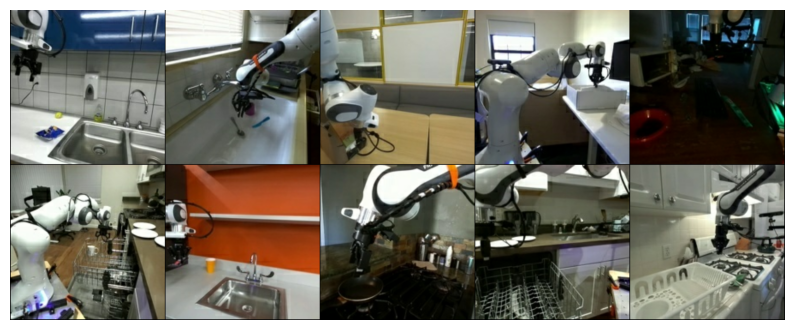

   📝 输入 ID 形状: torch.Size([10, 350])
   📝 输入 ID 类型: torch.int64
tensor([151644,   8948,    198,   2610,    525,    264,  12305,   6461,     13,
         20205,    389,   9124,   1946,    323,  11221,     11,   2677,   2550,
          6896,    220,     19,  41667,   1917,  11211,  11882,    504,    220,
        151679,   2503,    220, 151694,     13, 151645,    198, 151644,    872,
           198, 151671, 151671, 151671, 151671, 151671, 151671, 151671, 151671,
        151671, 151671, 151671, 151671, 151671])
<|im_start|>system

   📝 样本文本 : <|im_start|>system
You are a robot controller. Based on visual input and instructions, always output exactly 4 latent action tokens chosen from <ACT_0> ... <ACT_15>.<|im_end|>
<|im_start|>user
<IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><I

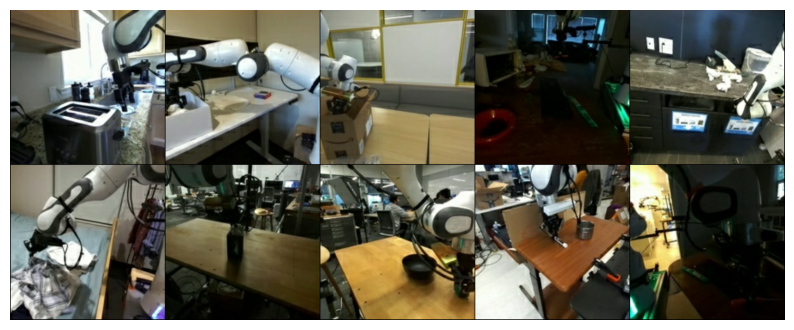

   📝 输入 ID 形状: torch.Size([10, 350])
   📝 输入 ID 类型: torch.int64
tensor([151644,   8948,    198,   2610,    525,    264,  12305,   6461,     13,
         20205,    389,   9124,   1946,    323,  11221,     11,   2677,   2550,
          6896,    220,     19,  41667,   1917,  11211,  11882,    504,    220,
        151679,   2503,    220, 151694,     13, 151645,    198, 151644,    872,
           198, 151671, 151671, 151671, 151671, 151671, 151671, 151671, 151671,
        151671, 151671, 151671, 151671, 151671])
<|im_start|>system

   📝 样本文本 : <|im_start|>system
You are a robot controller. Based on visual input and instructions, always output exactly 4 latent action tokens chosen from <ACT_0> ... <ACT_15>.<|im_end|>
<|im_start|>user
<IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><I

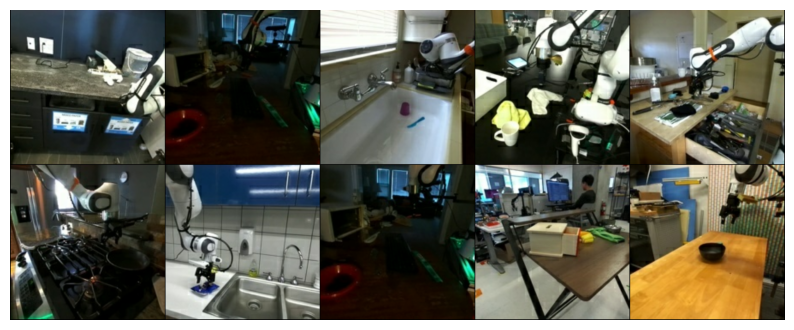

   📝 输入 ID 形状: torch.Size([10, 350])
   📝 输入 ID 类型: torch.int64
tensor([151644,   8948,    198,   2610,    525,    264,  12305,   6461,     13,
         20205,    389,   9124,   1946,    323,  11221,     11,   2677,   2550,
          6896,    220,     19,  41667,   1917,  11211,  11882,    504,    220,
        151679,   2503,    220, 151694,     13, 151645,    198, 151644,    872,
           198, 151671, 151671, 151671, 151671, 151671, 151671, 151671, 151671,
        151671, 151671, 151671, 151671, 151671])
<|im_start|>system

   📝 样本文本 : <|im_start|>system
You are a robot controller. Based on visual input and instructions, always output exactly 4 latent action tokens chosen from <ACT_0> ... <ACT_15>.<|im_end|>
<|im_start|>user
<IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><IMG_CONTEXT><I

In [12]:
# 测试 DataLoader 功能
def test_dataloader_functionality(dataloader, tokenizer, num_batches=3):
    """测试 DataLoader 的基本功能"""
    
    print("🧪 开始测试 DataLoader 功能...")
    
    try:
        # 获取迭代器
        dl_iter = iter(dataloader)
        
        # 测试前几个批次
        for batch_idx in range(num_batches):
            print(f"\n📦 测试批次 {batch_idx + 1}/{num_batches}")
            
            try:
                # 获取一个批次
                batch = next(dl_iter)
                
                print(f"   ✅ 批次 {batch_idx + 1} 获取成功")
                
                # 分析批次内容
                print(f"   📊 批次键: {list(batch.keys())}")
                
                # 检查关键字段
                if 'pixel_values' in batch:
                    pixel_values = batch['pixel_values']
                    print(f"   🖼️  图像张量形状: {pixel_values.shape}")
                    print(f"   🖼️  图像张量类型: {pixel_values.dtype}")
                    show_images(pixel_values, nrow=5)
                
                if 'input_ids' in batch:
                    input_ids = batch['input_ids']
                    print(f"   📝 输入 ID 形状: {input_ids.shape}")
                    print(f"   📝 输入 ID 类型: {input_ids.dtype}")
                    
                    # 解码一些 tokens 查看内容
                    if input_ids.numel() > 0:
                        sample_tokens = input_ids[0]  # 取前50个 tokens
                        print(sample_tokens[:50])
                        print(tokenizer.decode(sample_tokens[:3], skip_special_tokens=False))
                        decoded_text = tokenizer.decode(sample_tokens[batch['attention_mask'][0]==1], skip_special_tokens=False)
                        # decoded_text = tokenizer.decode(sample_tokens, skip_special_tokens=False)
                        print(f"   📝 样本文本 : {decoded_text}")
                
                if 'labels' in batch:
                    labels = batch['labels']
                    print(f"   🏷️  标签形状: {labels.shape}")
                    print(f"   🏷️  标签类型: {labels.dtype}")
                    
                    # 统计忽略的标签数量
                    ignore_count = (labels == -100).sum().item()
                    total_count = labels.numel()
                    print(labels[0][256:])
                    print(f"   🏷️  忽略标签比例: {ignore_count}/{total_count} ({ignore_count/total_count*100:.1f}%)")
                
                if 'dataset_name' in batch:
                    dataset_names = batch['dataset_name']
                    print(f"   📂 数据集名称: {dataset_names}")
                
                print(f"   ✅ 批次 {batch_idx + 1} 分析完成")
                
            except StopIteration:
                print(f"   ⚠️  数据集已耗尽，只测试了 {batch_idx} 个批次")
                break
            except Exception as e:
                print(f"   ❌ 批次 {batch_idx + 1} 处理失败: {e}")
                break
        
        print(f"\n✅ DataLoader 功能测试完成")
        return True
        
    except Exception as e:
        print(f"❌ DataLoader 测试失败: {e}")
        return False

# 执行 DataLoader 测试
if vla_dataset is not None and dataloader is not None:
    test_success = test_dataloader_functionality(dataloader, tokenizer, num_batches=3)
    if test_success:
        print("🎉 DataLoader 测试成功！")
    else:
        print("💥 DataLoader 测试失败！")
else:
    print("⚠️  跳过 DataLoader 测试（数据集或 DataLoader 未创建成功）")


In [13]:
print("198: ",tokenizer.convert_ids_to_tokens(198))

198:  Ċ


In [ ]:
# 测试模型前向传播
def test_model_forward_pass(vlm, dataloader, device):
    """测试模型前向传播"""
    
    print("🧪 开始测试模型前向传播...")
    
    try:
        # 设置模型为评估模式
        vlm.eval()
        
        # 获取一个批次进行测试
        dl_iter = iter(dataloader)
        batch = next(dl_iter)
        
        print("📦 获取测试批次成功")
        print(batch['pixel_values'].shape)
        # 将数据移动到设备
        if 'pixel_values' in batch:
            batch['pixel_values'] = batch['pixel_values'].to(device)
        if 'input_ids' in batch:
            batch['input_ids'] = batch['input_ids'].to(device)
        if 'labels' in batch:
            batch['labels'] = batch['labels'].to(device)
        
        print("🔄 数据已移动到设备")
        
        # 执行前向传播
        with torch.no_grad():
            print("🔄 执行前向传播...")
            
            # 调用模型前向传播
            outputs = vlm(
                pixel_values=batch['pixel_values'],
                input_ids=batch['input_ids'],
                labels=batch['labels'],
                attention_mask=batch["attention_mask"],
            )
            
            print("✅ 前向传播成功")
            
            # 分析输出
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
                print(f"📊 输出 logits 形状: {logits.shape}")
                print(f"📊 输出 logits 类型: {logits.dtype}")
                
                # 检查 action tokens 的预测
                if logits.numel() > 0:
                    # 获取最后一个 token 的预测
                    last_token_logits = logits[0, -1, :]
                    action_token_logits = last_token_logits[151679:151679+16]  # action token 范围
                    predicted_action_id = action_token_logits.argmax().item() + 151679
                    print(f"🎯 预测的 action token ID: {predicted_action_id}")
                    print(f"🎯 对应的 action token: <ACT_{predicted_action_id-151679}>")
            
            if hasattr(outputs, 'loss'):
                loss = outputs.loss
                print(f"📉 损失值: {loss.item():.4f}")
            
            print("✅ 模型前向传播测试完成")
            return True
            
    except Exception as e:
        print(f"❌ 模型前向传播测试失败: {e}")
        import traceback
        traceback.print_exc()
        return False

# 执行模型前向传播测试
if vlm is not None and dataloader is not None:
    forward_success = test_model_forward_pass(vlm, dataloader, device, num_batches=1)
    if forward_success:
        print("🎉 模型前向传播测试成功！")
    else:
        print("💥 模型前向传播测试失败！")
else:
    print("⚠️  跳过模型前向传播测试（模型或 DataLoader 未创建成功）")


🧪 开始测试模型前向传播...


W0000 00:00:1757567966.289880 2055539 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 1 } dim { size: 448 } dim { size: 448 } dim { size: -14 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } } device { type: "CPU" vendor: "GenuineIntel" model: "106" frequency: 3000 num_cores: 128 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 1310720 l3_cache_size: 50331648 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: -16 } dim { size: -17 } dim { size: -14 } } }
W0000 00:00:17575679

📦 获取测试批次成功
torch.Size([10, 3, 448, 448])
🔄 数据已移动到设备
🔄 执行前向传播...
✅ 前向传播成功
📊 输出 logits 形状: torch.Size([10, 293, 151936])
📊 输出 logits 类型: torch.float32
🎯 预测的 action token ID: 151687
🎯 对应的 action token: <ACT_8>
📉 损失值: 14.9858
✅ 模型前向传播测试完成
🎉 模型前向传播测试成功！
